In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('digit.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [6]:
x=df.iloc[:,1:785]
print(x)
print(x.shape)
y=df.iloc[:,0]
print(y)
print(y.shape)

       pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995       0       0       0       0       0       0       0       0       0   
41996       0       0       0       0       0       0       0       0       0   
41997       0       0       0       0       0       0       0       0       0   
41998       0       0       0       0       0       0       0       0       0   
41999       0       0       0       0       0       0       0       0       0   

       pixel9  ...  pixel77

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(33600, 784)
(8400, 784)
(33600,)
(8400,)


In [7]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [11]:
y_pred=model.predict(x_test)
print(y_pred)

#compareing actual and predicted values
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[8 1 9 ... 3 0 9]
[[804   0   1   1   1   1   4   0   3   1]
 [  0 902   2   1   1   2   1   0   0   0]
 [  4   3 811   3   9   1   4   5   6   0]
 [  1   2   9 880   1  13   0  10  10  11]
 [  1   0   1   0 815   0   6   1   0  15]
 [  1   1   1  11   1 667   9   1   5   5]
 [  4   1   1   0   2   3 768   0   6   0]
 [  1   2  10   1   5   1   0 853   2  18]
 [  0   5   4   7   7   4   2   3 795   8]
 [  2   3   2  16   7   4   0   7   4 793]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       816
           1       0.98      0.99      0.99       909
           2       0.96      0.96      0.96       846
           3       0.96      0.94      0.95       937
           4       0.96      0.97      0.97       839
           5       0.96      0.95      0.95       702
           6       0.97      0.98      0.97       785
           7       0.97      0.96      0.96       893
           8       0.96      0.95      0.95       835
          

In [12]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9628571428571429


predicted value:[8]


c:\Users\91965\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


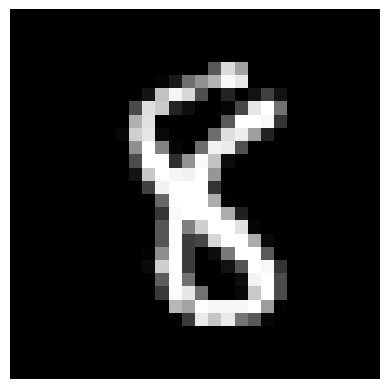

In [14]:
index=600

print("predicted value:"+str(model.predict(x_test.iloc[index].values.reshape(1,-1))))
plt.axis('off')
plt.imshow(x_test.iloc[index].values.reshape(28,28),cmap='gray')